# Q3: 买多少？

Q2 我们从全市场中筛选出了 3 只 ETF：沪深300、纳指100、黄金。但关键问题还没回答：**每只各买多少？**

等分？各买三分之一？还是有更聪明的分法？

### 路线图

**选什么标的（Q2 ✓）→ 每个买多少（Q3）→ 什么时候买卖（Q4）→ 怎么验证有效（Q5）**

本章解决第二步。分两个小步回答：**最简单的分法 → 更聪明的分法**

铁律不变：**先猜后验，数据说了算。**

### 前置条件

- 已完成 Q2
- 已安装 open-xquant：`pip install open-xquant[yfinance]`

### 操作方式

和前面一样：阅读说明 → 打开对应 spec → 复制到 TRAE → 观察结果 → 回来看解读。

---

## Step 1: 最简单的回答——各买三分之一

三只 ETF，各买多少？最自然的想法：**平均分，公平合理，各买 1/3。** 这个答案好不好？我们跑一遍看看。

👉 **打开 `specs/spec-01-equal-weight.md`，复制到 TRAE。**

In [1]:
from oxq.core import Engine, Strategy
from oxq.data import YFinanceDownloader, LocalMarketDataProvider
from oxq.indicators import RollingVolatility
from oxq.signals import EqualWeight
from oxq.rules import RebalanceRule
from oxq.trade import SimBroker
from oxq.universe import StaticUniverse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False

# 常量
SYMBOLS = ("510300.SS", "513100.SS", "518880.SS")
SYMBOL_NAMES = {
    "510300.SS": "沪深300ETF",
    "513100.SS": "纳指100ETF",
    "518880.SS": "黄金ETF",
}
START = "2021-01-01"
today = pd.Timestamp.now().strftime("%Y-%m-%d")

# 下载数据
downloader = YFinanceDownloader()
for sym in SYMBOLS:
    downloader.download(sym, start=START, end=today)

# 构建投资宇宙
universe = StaticUniverse(symbols=SYMBOLS, name="global-macro-etf")

# 加载数据并预计算波动率
market = LocalMarketDataProvider()
mktdata = {}
for sym in SYMBOLS:
    d = market.get_bars(sym, START, today).copy()
    d["vol"] = RollingVolatility().compute(d, column="close", period=20)
    mktdata[sym] = d

print("数据加载完成")
for sym in SYMBOLS:
    print(f"  {SYMBOL_NAMES[sym]}: {len(mktdata[sym])} 个交易日")

数据加载完成
  沪深300ETF: 1247 个交易日
  纳指100ETF: 1248 个交易日
  黄金ETF: 1247 个交易日


In [2]:
# 计算等权权重
ew_weights = EqualWeight().compute(mktdata)

# 打印某一天的权重
sample_date = mktdata[SYMBOLS[0]].index[-1]
print(f"等权权重（{sample_date.strftime('%Y-%m-%d')}）：")
for sym in SYMBOLS:
    w = ew_weights[sym].iloc[-1]
    print(f"  {SYMBOL_NAMES[sym]}: {w:.1%}")

# 10 万元换算
total_capital = 100_000
print(f"\n假如你有 {total_capital:,} 元：")
for sym in SYMBOLS:
    w = ew_weights[sym].iloc[-1]
    amount = total_capital * w
    print(f"  {SYMBOL_NAMES[sym]}: {amount:,.0f} 元 (权重 {w:.1%})")

print("\n权重（Weight）就是\u201c这笔钱怎么分\u201d——每只标的分到总资金的百分之多少。")

等权权重（2026-03-03）：
  沪深300ETF: 33.3%
  纳指100ETF: 33.3%
  黄金ETF: 33.3%

假如你有 100,000 元：
  沪深300ETF: 33,333 元 (权重 33.3%)
  纳指100ETF: 33,333 元 (权重 33.3%)
  黄金ETF: 33,333 元 (权重 33.3%)

权重（Weight）就是“这笔钱怎么分”——每只标的分到总资金的百分之多少。


In [3]:
# 三只 ETF 单独持有的表现
single_metrics = {}
for sym in SYMBOLS:
    close = mktdata[sym]["close"]
    cum_return = close.iloc[-1] / close.iloc[0] - 1
    daily_ret = close.pct_change().dropna()
    annual_vol = daily_ret.std() * np.sqrt(252)
    cummax = close.cummax()
    max_dd = ((close - cummax) / cummax).min()
    single_metrics[sym] = {
        "cum_return": cum_return,
        "annual_vol": annual_vol,
        "max_dd": max_dd,
    }

# 等权策略回测
strategy_ew = Strategy(
    name="equal-weight",
    universe=universe,
    indicators={
        "vol": (RollingVolatility(), {"column": "close", "period": 20}),
    },
    signals={"tw": (EqualWeight(), {})},
    entry_rules=[],
    exit_rules=[],
    rebalance_rules=[RebalanceRule(weight_col="tw", frequency=10)],
)

broker = SimBroker()
result_ew = Engine().run(
    strategy_ew,
    market=LocalMarketDataProvider(),
    router=broker,
    receiver=broker,
    start=START,
    end=today,
)

# 对比表
print("\n各标的表现对比")
print("=" * 60)
print(f"{'标的':<12} {'累计收益率':>10} {'年化波动率':>10} {'最大回撤':>10}")
print("-" * 60)
for sym in SYMBOLS:
    m = single_metrics[sym]
    print(f"{SYMBOL_NAMES[sym]:<12} {m['cum_return']:>10.2%} {m['annual_vol']:>10.2%} {m['max_dd']:>10.2%}")

ew_ret = result_ew.total_return()
ew_vol = result_ew.annualized_volatility()
ew_dd = result_ew.max_drawdown()
print("-" * 60)
print(f"{'等权组合':<12} {ew_ret:>10.2%} {ew_vol:>10.2%} {ew_dd:>10.2%}")


各标的表现对比
标的                累计收益率      年化波动率       最大回撤
------------------------------------------------------------
沪深300ETF         -1.78%     18.11%    -42.16%
纳指100ETF        106.09%     22.66%    -27.50%
黄金ETF           188.54%     15.83%    -16.77%
------------------------------------------------------------
等权组合             80.75%     11.73%    -16.79%


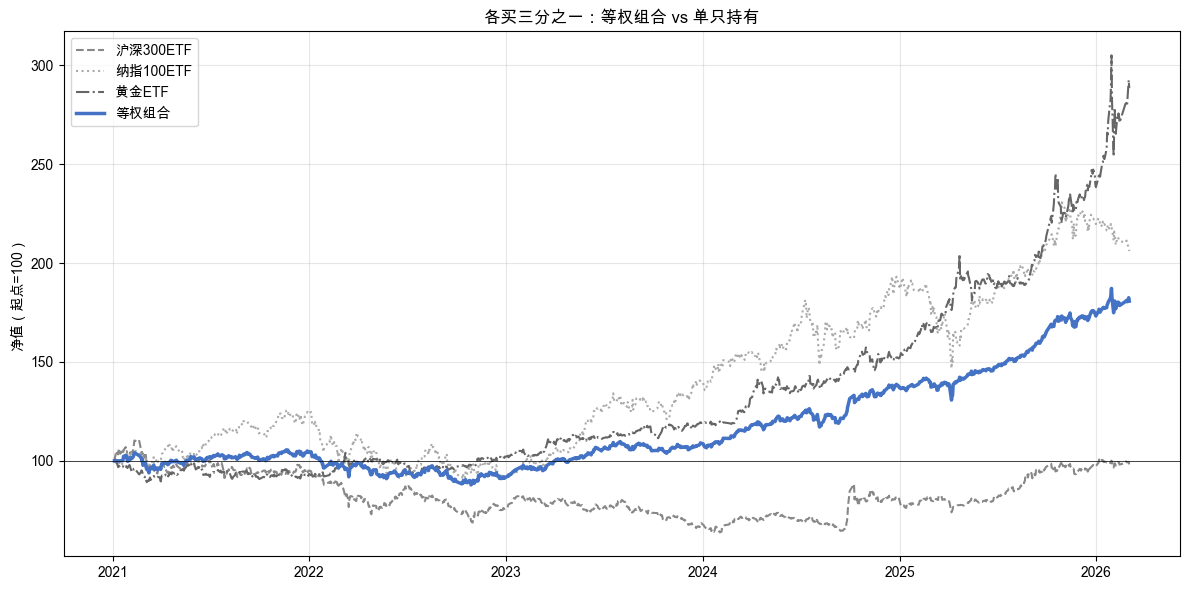


三只 ETF 各自的年化波动率从 15.83% 到 22.66%，差了 1.4 倍。
但等权信号说：不管你多颠簸，都买一样多的钱。
波动最大的纳指100ETF，虽然只花了 1/3 的钱，却主导了组合的涨跌。

有没有更聪明的分法——比如，波动大的少买点？


In [4]:
# 净值曲线对比图
fig, ax = plt.subplots(figsize=(12, 6))

# 取三个市场共同交易日（消除中美交易日历差异导致的净值跳变）
common_trading_days = mktdata[SYMBOLS[0]].index
for sym in SYMBOLS[1:]:
    common_trading_days = common_trading_days.intersection(mktdata[sym].index)

styles = [('--', '#888888'), (':', '#AAAAAA'), ('-.', '#666666')]
for i, sym in enumerate(SYMBOLS):
    close = mktdata[sym]["close"].reindex(common_trading_days)
    norm = close / close.iloc[0] * 100
    ls, color = styles[i]
    ax.plot(norm.index, norm.values, label=SYMBOL_NAMES[sym],
            linestyle=ls, color=color, linewidth=1.5)

# 等权组合净值（equity_curve 是 list[tuple]，需转为 Series）
equity = pd.Series(dict(result_ew.equity_curve))
equity = equity.reindex(common_trading_days).dropna()
equity_norm = equity / equity.iloc[0] * 100
ax.plot(equity_norm.index, equity_norm.values, label='等权组合',
        color='#4472C4', linewidth=2.5)

ax.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('净值（起点=100）')
ax.set_title('各买三分之一：等权组合 vs 单只持有')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../book/images/01-equal-weight-nav.png", dpi=150, bbox_inches='tight')
plt.show()

# 分析
vols = [single_metrics[sym]['annual_vol'] for sym in SYMBOLS]
min_vol_name = SYMBOL_NAMES[SYMBOLS[np.argmin(vols)]]
max_vol_name = SYMBOL_NAMES[SYMBOLS[np.argmax(vols)]]
print(f"\n三只 ETF 各自的年化波动率从 {min(vols):.2%} 到 {max(vols):.2%}，差了 {max(vols)/min(vols):.1f} 倍。")
print(f"但等权信号说：不管你多颠簸，都买一样多的钱。")
print(f"波动最大的{max_vol_name}，虽然只花了 1/3 的钱，却主导了组合的涨跌。")
print(f"\n有没有更聪明的分法——比如，波动大的少买点？")

### Step 1 解读

等权组合的逻辑很简单：不管三只 ETF 各自什么脾气，一律平均分钱。

但数据告诉我们一个问题：**三只 ETF 的波动率差了好几倍。** 波动大的那只虽然只花了 1/3 的钱，却主导了整个组合的涨跌——平均分钱 ≠ 平均分影响。

那如果我们不平均分钱，而是**按波动来分**呢？波动大的少买点、波动小的多买点——组合是不是会更稳？

先猜后验。

---

## Step 2: 波动大的少买点，波动小的多买点

直觉告诉我们：波动大的少买、波动小的多买，组合应该更稳。我们来验证。

👉 **打开 `specs/spec-02-risk-parity.md`，复制到 TRAE。**

In [5]:
from oxq.signals import RiskParity

# 计算风险平价权重
rp_weights = RiskParity().compute(mktdata, vol="vol")

# 权重对比
sample_date = mktdata[SYMBOLS[0]].index[-1]
print(f"权重对比（{sample_date.strftime('%Y-%m-%d')}）：")
print(f"{'标的':<12} {'等权权重':>10} {'风险平价权重':>12}")
print("-" * 40)
for sym in SYMBOLS:
    ew_w = ew_weights[sym].iloc[-1]
    rp_w = rp_weights[sym].iloc[-1]
    print(f"{SYMBOL_NAMES[sym]:<12} {ew_w:>10.1%} {rp_w:>12.1%}")

# 10 万元换算对比
print(f"\n同样 {total_capital:,} 元：")
print("  等权：", end="")
print(" / ".join(f"{SYMBOL_NAMES[s]} 买 {total_capital * ew_weights[s].iloc[-1]:,.0f} 元" for s in SYMBOLS))
print("  风险平价：", end="")
print(" / ".join(f"{SYMBOL_NAMES[s]} 买 {total_capital * rp_weights[s].iloc[-1]:,.0f} 元" for s in SYMBOLS))

权重对比（2026-03-03）：
标的                 等权权重       风险平价权重
----------------------------------------
沪深300ETF          33.3%        45.5%
纳指100ETF          33.3%        43.3%
黄金ETF             33.3%        11.2%

同样 100,000 元：
  等权：沪深300ETF 买 33,333 元 / 纳指100ETF 买 33,333 元 / 黄金ETF 买 33,333 元
  风险平价：沪深300ETF 买 45,510 元 / 纳指100ETF 买 43,251 元 / 黄金ETF 买 11,239 元


In [6]:
# 风险平价策略回测
COMMON = dict(
    universe=universe,
    indicators={
        "vol": (RollingVolatility(), {"column": "close", "period": 20}),
    },
    entry_rules=[],
    exit_rules=[],
    rebalance_rules=[RebalanceRule(weight_col="tw", frequency=10)],
)

strategy_rp = Strategy(
    name="risk-parity",
    signals={"tw": (RiskParity(), {"vol": "vol"})},
    **COMMON,
)

broker_rp = SimBroker()
result_rp = Engine().run(
    strategy_rp,
    market=LocalMarketDataProvider(),
    router=broker_rp,
    receiver=broker_rp,
    start=START,
    end=today,
)

# 指标对比表
rp_ret = result_rp.total_return()
rp_vol = result_rp.annualized_volatility()
rp_dd = result_rp.max_drawdown()

print("\n等权 vs 风险平价")
print("=" * 50)
print(f"{'指标':<12} {'等权组合':>12} {'风险平价组合':>14}")
print("-" * 50)
print(f"{'累计收益率':<12} {ew_ret:>12.2%} {rp_ret:>14.2%}")
print(f"{'年化波动率':<12} {ew_vol:>12.2%} {rp_vol:>14.2%}")
print(f"{'最大回撤':<12} {ew_dd:>12.2%} {rp_dd:>14.2%}")


等权 vs 风险平价
指标                   等权组合         风险平价组合
--------------------------------------------------
累计收益率              80.75%         99.67%
年化波动率              11.73%         10.81%
最大回撤              -16.79%        -12.26%


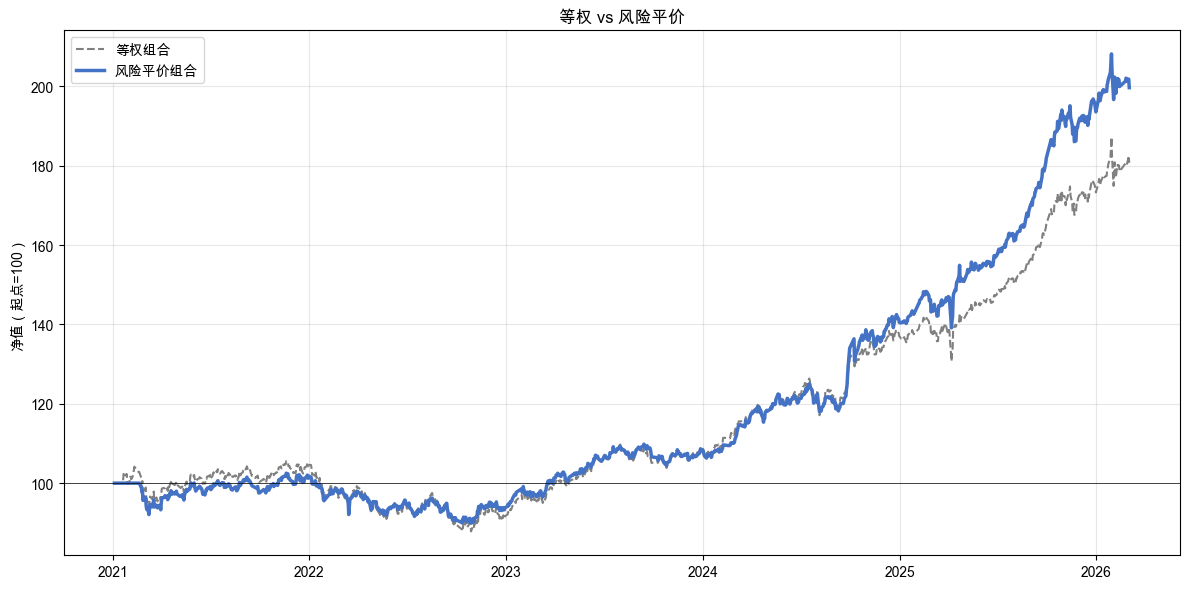

In [7]:
# 净值曲线对比（仅共同交易日，避免日历差异造成锯齿）
fig, ax = plt.subplots(figsize=(12, 6))

eq_ew = pd.Series(dict(result_ew.equity_curve)).reindex(common_trading_days).dropna()
eq_rp = pd.Series(dict(result_rp.equity_curve)).reindex(common_trading_days).dropna()
eq_ew_norm = eq_ew / eq_ew.iloc[0] * 100
eq_rp_norm = eq_rp / eq_rp.iloc[0] * 100

ax.plot(eq_ew_norm.index, eq_ew_norm.values, label='等权组合',
        linestyle='--', color='gray', linewidth=1.5)
ax.plot(eq_rp_norm.index, eq_rp_norm.values, label='风险平价组合',
        color='#4472C4', linewidth=2.5)

ax.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('净值（起点=100）')
ax.set_title('等权 vs 风险平价')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../book/images/02-ew-vs-rp-nav.png", dpi=150, bbox_inches='tight')
plt.show()

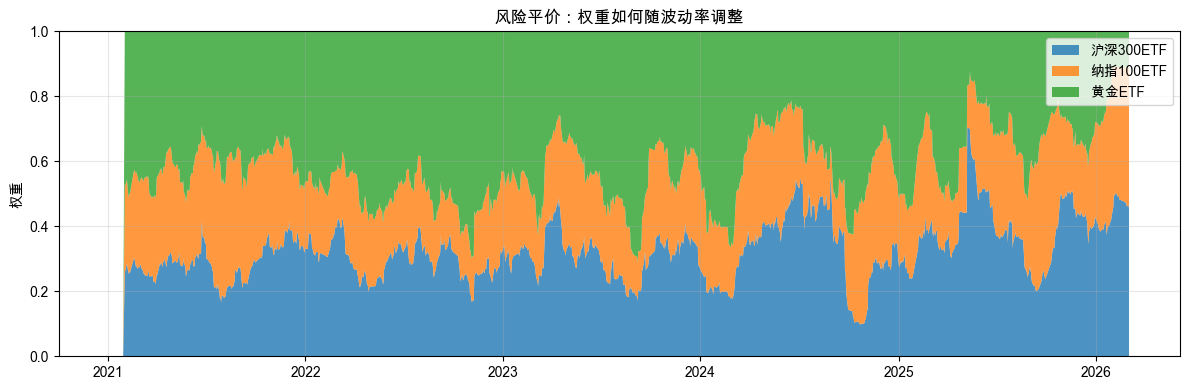

波动大的少买点、波动小的多买点——
组合波动率从 11.73% 降到 10.81%，最大回撤从 -16.79% 收窄到 -12.26%。

这种方法叫风险平价（Risk Parity）——让每个资产对组合波动的贡献一样大。
桥水基金的‘全天候策略’用的就是这个思路。


In [8]:
# 权重变化历史图
fig, ax = plt.subplots(figsize=(12, 4))

# 对齐日期
common_dates = rp_weights[SYMBOLS[0]].index
weight_df = pd.DataFrame({
    SYMBOL_NAMES[sym]: rp_weights[sym].reindex(common_dates)
    for sym in SYMBOLS
}).dropna()

ax.stackplot(weight_df.index, [weight_df[SYMBOL_NAMES[s]].values for s in SYMBOLS],
             labels=[SYMBOL_NAMES[s] for s in SYMBOLS],
             alpha=0.8)
ax.set_ylabel('权重')
ax.set_title('风险平价：权重如何随波动率调整')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../book/images/03-rp-weight-history.png", dpi=150, bbox_inches='tight')
plt.show()

# 分析
print(f"波动大的少买点、波动小的多买点——")
print(f"组合波动率从 {ew_vol:.2%} 降到 {rp_vol:.2%}，最大回撤从 {ew_dd:.2%} 收窄到 {rp_dd:.2%}。")
print(f"\n这种方法叫风险平价（Risk Parity）——让每个资产对组合波动的贡献一样大。")
print(f"桥水基金的\u2018全天候策略\u2019用的就是这个思路。")

### Step 2 解读

权重对比表一目了然：风险平价给波动低的资产分配了更多的钱，给波动高的分配了更少的钱。

效果呢？**波动率降了，回撤也小了。** 堆叠面积图还展示了一个细节：权重不是一成不变的——随着市场波动变化，每只 ETF 分到的比例也在动态调整。

这种方法叫**风险平价（Risk Parity）**。名字听起来高级，道理很朴素：

> 想象你要把一笔钱交给三个人打理。一个人成熟稳重，赚了不炫亏了不慌；一个人喜怒无常，今天信心爆棚明天就要清仓；第三个人介于两者之间。你会怎么分？肯定是稳重的那个多管点钱，情绪化的那个少管点。三只 ETF也一样——波动率就是它们的"情绪起伏程度"。波动小的稳重，多买；波动大的情绪化，少买。这就是按波动率倒数分配权重的直觉。

这里的"情绪"就是波动率，"管理钱"就是主导了组合的涨跌。波动大的少买点、波动小的多买点。桥水基金的"全天候策略"用的就是这个思路。

**数据说了算：按波动调整比例，确实比拍脑袋平均分更稳。**

---

## Step 3: 涨得好的多买点，跌的别买

风险平价更稳了，但它只看波动率，完全不看涨跌。如果一只 ETF 正在猛涨，风险平价不会多买它；如果一只在跌，也不会少买它。

能不能让涨得好的多买点、正在跌的干脆不买？先猜后验。

👉 **打开 `specs/spec-03-momentum-ranking.md`，复制到 TRAE。**

In [9]:
from oxq.signals import TopNRanking
from oxq.indicators import Momentum, Ratio

# 为每只 ETF 预计算 20 日动量
for sym in SYMBOLS:
    mktdata[sym]["mom"] = Momentum().compute(mktdata[sym], column="close", period=20)
    mktdata[sym]["ram"] = Ratio().compute(mktdata[sym], col_a="mom", col_b="vol")

# 计算动量排名权重
tn_weights = TopNRanking().compute(mktdata, score="ram", n=3, filter_negative=True)

# 三种信号权重对比
sample_date = mktdata[SYMBOLS[0]].index[-1]
print(f"三种信号权重对比（{sample_date.strftime('%Y-%m-%d')}）：")
print(f"{'标的':<12} {'等权':>8} {'风险平价':>10} {'动量排名':>10}")
print("-" * 46)
for sym in SYMBOLS:
    ew_w = ew_weights[sym].iloc[-1]
    rp_w = rp_weights[sym].iloc[-1]
    tn_w = tn_weights[sym].iloc[-1]
    print(f"{SYMBOL_NAMES[sym]:<12} {ew_w:>8.1%} {rp_w:>10.1%} {tn_w:>10.1%}")

三种信号权重对比（2026-03-03）：
标的                 等权       风险平价       动量排名
----------------------------------------------
沪深300ETF        33.3%      45.5%       0.0%
纳指100ETF        33.3%      43.3%       0.0%
黄金ETF           33.3%      11.2%     100.0%


In [10]:
# 动量排名策略回测
COMMON_WITH_MOM = dict(
    universe=universe,
    indicators={
        "vol": (RollingVolatility(), {"column": "close", "period": 20}),
        "mom": (Momentum(), {"column": "close", "period": 20}),
        "vol": (RollingVolatility(), {"column": "close", "period": 20}),
        "ram": (Ratio(), {"col_a": "mom", "col_b": "vol"}),
    },
    entry_rules=[],
    exit_rules=[],
    rebalance_rules=[RebalanceRule(weight_col="tw", frequency=10)],
)

strategy_tn = Strategy(
    name="momentum-ranking",
    signals={"tw": (TopNRanking(), {"score": "ram", "n": 3, "filter_negative": True})},
    **COMMON_WITH_MOM,
)

broker_tn = SimBroker()
result_tn = Engine().run(
    strategy_tn,
    market=LocalMarketDataProvider(),
    router=broker_tn,
    receiver=broker_tn,
    start=START,
    end=today,
)

# 三方指标对比
tn_ret = result_tn.total_return()
tn_vol = result_tn.annualized_volatility()
tn_dd = result_tn.max_drawdown()

print("\n三种信号对比")
print("=" * 56)
print(f"{'指标':<12} {'等权':>10} {'风险平价':>12} {'动量排名':>12}")
print("-" * 56)
print(f"{'累计收益率':<12} {ew_ret:>10.2%} {rp_ret:>12.2%} {tn_ret:>12.2%}")
print(f"{'年化波动率':<12} {ew_vol:>10.2%} {rp_vol:>12.2%} {tn_vol:>12.2%}")
print(f"{'最大回撤':<12} {ew_dd:>10.2%} {rp_dd:>12.2%} {tn_dd:>12.2%}")


三种信号对比
指标                   等权         风险平价         动量排名
--------------------------------------------------------
累计收益率            80.75%       99.67%      179.96%
年化波动率            11.73%       10.81%       15.54%
最大回撤            -16.79%      -12.26%      -15.77%


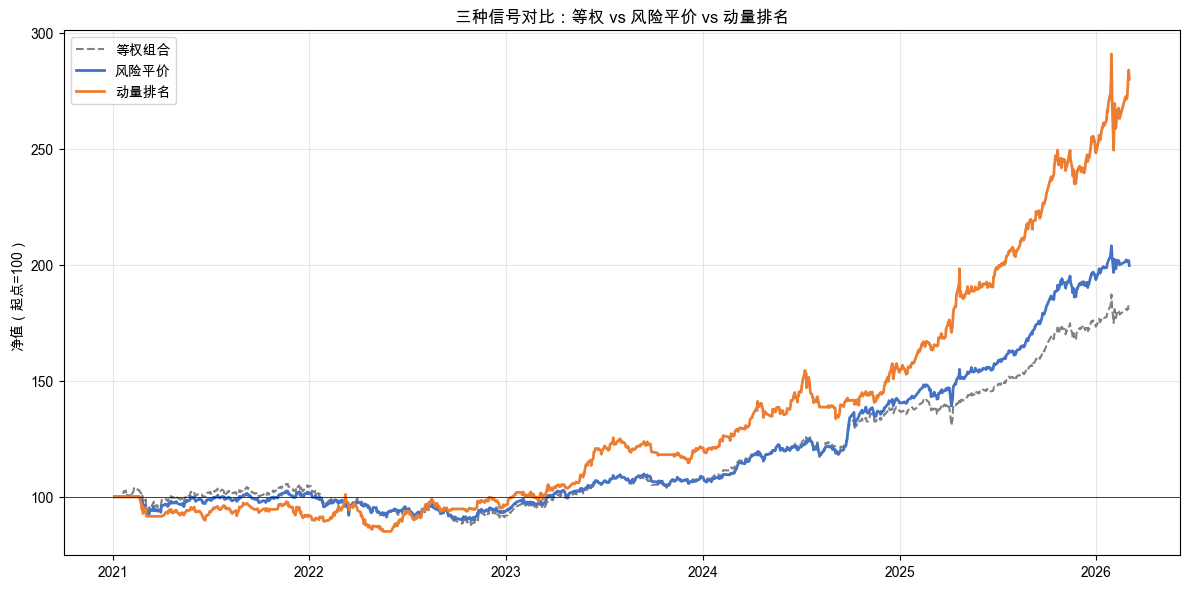

In [11]:
# 三条净值曲线对比
fig, ax = plt.subplots(figsize=(12, 6))

eq_ew = pd.Series(dict(result_ew.equity_curve)).reindex(common_trading_days).dropna()
eq_rp = pd.Series(dict(result_rp.equity_curve)).reindex(common_trading_days).dropna()
eq_tn = pd.Series(dict(result_tn.equity_curve)).reindex(common_trading_days).dropna()
eq_ew_norm = eq_ew / eq_ew.iloc[0] * 100
eq_rp_norm = eq_rp / eq_rp.iloc[0] * 100
eq_tn_norm = eq_tn / eq_tn.iloc[0] * 100

ax.plot(eq_ew_norm.index, eq_ew_norm.values, label='等权组合',
        linestyle='--', color='gray', linewidth=1.5)
ax.plot(eq_rp_norm.index, eq_rp_norm.values, label='风险平价',
        color='#4472C4', linewidth=2)
ax.plot(eq_tn_norm.index, eq_tn_norm.values, label='动量排名',
        color='#ED7D31', linewidth=2)

ax.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('净值（起点=100）')
ax.set_title('三种信号对比：等权 vs 风险平价 vs 动量排名')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../book/images/04-three-signals-nav.png", dpi=150, bbox_inches='tight')
plt.show()

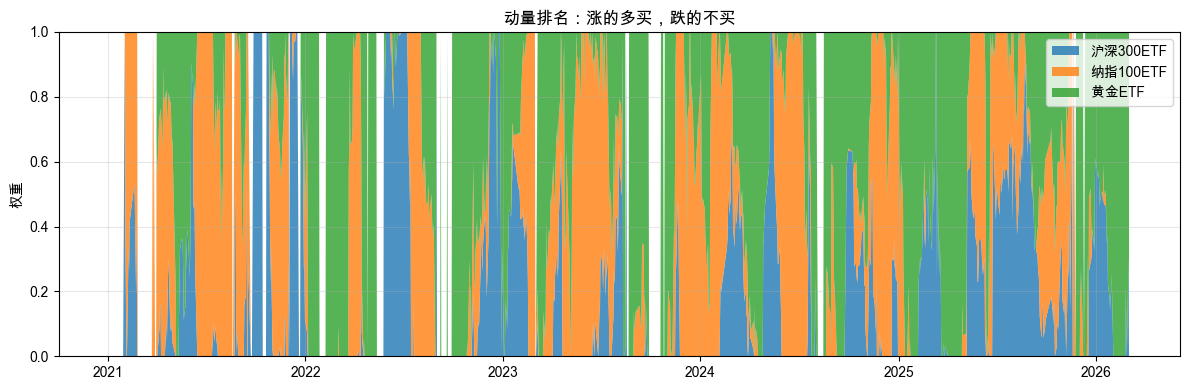

动量排名更激进——涨势好的时候集中加仓，跌的直接不买。
收益率从 99.67%（风险平价）提升到 179.96%（动量排名）。
波动率更大了（10.81% → 15.54%），回撤更深了（-12.26% → -15.77%）。

没有完美的分法——风险平价求稳，动量排名求收益。选哪个，取决于你更怕亏还是更想赚。


In [12]:
# 动量排名权重变化历史图
fig, ax = plt.subplots(figsize=(12, 4))

weight_tn_df = pd.DataFrame({
    SYMBOL_NAMES[sym]: tn_weights[sym].reindex(common_trading_days)
    for sym in SYMBOLS
}).dropna()

ax.stackplot(weight_tn_df.index,
             [weight_tn_df[SYMBOL_NAMES[s]].values for s in SYMBOLS],
             labels=[SYMBOL_NAMES[s] for s in SYMBOLS],
             alpha=0.8)
ax.set_ylabel('权重')
ax.set_title('动量排名：涨的多买，跌的不买')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../book/images/05-momentum-weight-history.png", dpi=150, bbox_inches='tight')
plt.show()

# 分析
print(f"动量排名更激进——涨势好的时候集中加仓，跌的直接不买。")
print(f"收益率从 {rp_ret:.2%}（风险平价）{'提升' if tn_ret > rp_ret else '下降'}到 {tn_ret:.2%}（动量排名）。")
vol_dir = "更大" if tn_vol > rp_vol else "更小"
dd_dir = "更深" if tn_dd < rp_dd else "更浅"
print(f"波动率{vol_dir}了（{rp_vol:.2%} \u2192 {tn_vol:.2%}），回撤{dd_dir}了（{rp_dd:.2%} \u2192 {tn_dd:.2%}）。")
print(f"\n没有完美的分法——风险平价求稳，动量排名求收益。选哪个，取决于你更怕亏还是更想赚。")

### Step 3 解读

动量排名权重的堆叠图很有意思：有些时段某只 ETF 的面积完全消失了——那是因为它的动量为负（正在跌），信号直接把它踢出了组合。

这跟前两种信号有本质区别：等权和风险平价永远持有全部三只 ETF，只是比例不同。动量排名则会**主动放弃正在跌的标的**，把钱集中给涨势好的。

效果如何？看上面的数据。不同的参数、不同的时间段，结果可能不同——这正是"先猜后验，数据说了算"的意义。

**数据说了算：没有完美的分法。** 稳和收益之间永远有取舍。这三种信号就是三种不同的取舍方式。

### 综合评判：每承受一份颠簸，换回了多少收益？

三种方案摆在面前：等权最简单、风险平价最稳、动量排名收益最高。但收益高的波动也大——怎么综合判断？

一个直觉的想法：**拿收益除以波动。** 谁的"性价比"最高——每承受一份颠簸，换回了更多的收益——谁就更好。

这个比值有个正式的名字：**夏普比率（Sharpe Ratio）**。

In [13]:
# 夏普比率对比
ew_sharpe = result_ew.sharpe_ratio()
rp_sharpe = result_rp.sharpe_ratio()
tn_sharpe = result_tn.sharpe_ratio()

ew_ann_ret = result_ew.annualized_return()
rp_ann_ret = result_rp.annualized_return()
tn_ann_ret = result_tn.annualized_return()

print("三种信号完整对比")
print("=" * 62)
print(f"{'指标':<12} {'等权':>12} {'风险平价':>14} {'动量排名':>14}")
print("-" * 62)
print(f"{'累计收益率':<12} {ew_ret:>12.2%} {rp_ret:>14.2%} {tn_ret:>14.2%}")
print(f"{'年化收益率':<12} {ew_ann_ret:>12.2%} {rp_ann_ret:>14.2%} {tn_ann_ret:>14.2%}")
print(f"{'年化波动率':<12} {ew_vol:>12.2%} {rp_vol:>14.2%} {tn_vol:>14.2%}")
print(f"{'最大回撤':<12} {ew_dd:>12.2%} {rp_dd:>14.2%} {tn_dd:>14.2%}")
print(f"{'夏普比率':<12} {ew_sharpe:>12.2f} {rp_sharpe:>14.2f} {tn_sharpe:>14.2f}")

print(f"\n夏普比率（Sharpe Ratio）= 年化收益率 / 年化波动率")
print(f"它衡量的是\u201c每承受一份颠簸，换回了多少收益\u201d。数字越大，性价比越高。")

# 找出夏普比最高的
sharpes = {"等权": ew_sharpe, "风险平价": rp_sharpe, "动量排名": tn_sharpe}
best = max(sharpes, key=sharpes.get)
print(f"\n三种方案中，{best}的夏普比率最高（{sharpes[best]:.2f}）——同样的颠簸程度下，它赚得最多。")

三种信号完整对比
指标                     等权           风险平价           动量排名
--------------------------------------------------------------
累计收益率              80.75%         99.67%        179.96%
年化收益率              11.96%         13.97%         20.80%
年化波动率              11.73%         10.81%         15.54%
最大回撤              -16.79%        -12.26%        -15.77%
夏普比率                 1.08           1.35           1.42

夏普比率（Sharpe Ratio）= 年化收益率 / 年化波动率
它衡量的是“每承受一份颠簸，换回了多少收益”。数字越大，性价比越高。

三种方案中，动量排名的夏普比率最高（1.42）——同样的颠簸程度下，它赚得最多。


### 夏普比率的适用边界

夏普比率是一个好用的起点，但它不是万能的：

1. **它把上涨和下跌的波动一视同仁。** 波动率既包含"涨得猛"也包含"跌得狠"。一个策略因为暴涨而波动大，夏普比会惩罚它——但你可能并不介意往上的颠簸。

2. **它假设收益率服从正态分布。** 真实市场中，暴跌的频率远高于正态分布的预测（肥尾效应）。夏普比会低估极端风险。

3. **数字本身没有绝对标准。** 夏普比 1.0 算好还是差？取决于时间段、市场环境、对比基准。同一个策略，换个时间段跑，夏普比可能完全不同。

4. **波动率为 0 时它会失效。** 如果一个策略全程持有现金，波动率为 0，夏普比就变成无穷大——但显然"不做任何投资"不是最好的策略。分母为 0 就没有意义了。

**总结：夏普比适合在相同条件下对比几个方案的性价比，但不要把它当成唯一的评判标准。** 单看任何一个指标都可能被误导——怎么综合多个指标做判断，我们在 Q5 会详细讲。

---

## 回头看：你刚才做了什么？

### 信号（Signal）

回顾本章做的三件事：等权分配、按波动调整、按动量调整。它们的共同点是什么？都在回答同一个问题：**每只买百分之多少。**

在量化交易中，这种告诉策略该怎么做的指令叫做**信号（Signal）**。

Q1 的均线策略也有信号——收盘价上穿均线时发出买入指令，下穿时发出卖出指令。那个信号回答的是**买还是不买**，只有两种可能。

本章的信号升级了：不再是简单的买或不买，而是**每只买多少比例**——一组数字。三种信号，三种思路：

| 信号 | 思路 | 特点 |
|------|------|------|
| EqualWeight | 什么都不看，平均分 | 最简单 |
| RiskParity | 看波动率，稳优先 | 更稳、回撤小 |
| TopNRanking | 看涨势，跟动量走 | 收益高、但颠簸大 |

```
Q2: 买什么 → Universe（投资宇宙）
Q3: 买多少 → Signal（信号）——告诉策略每只买百分之多少
Q4: 什么时候 → Rules（规则）——决定何时执行
```

**信号就是策略的大脑——它做判断，但不动手。动手的是规则。**

### 再平衡（Rebalancing）

权重不是一成不变的——波动率在变、动量在变，权重也要跟着调。我们的回测中，每 21 个交易日（大约一个月）重新计算一次权重并调整仓位，这个过程叫**再平衡（Rebalancing）**。调多频繁、怎么调，是另一个重要的设计选择。这些问题我们留到 Q4 一起解决。

---

## 本章总结

### 三步优化

```
Q2 产出：投资宇宙 {沪深300, 纳指100, 黄金}
    ↓ Step 1: 各买 1/3（等权信号）→ 简单但波动大的主导了组合
    ↓ Step 2: 按波动调整（风险平价信号）→ 更稳、回撤更小
    ↓ Step 3: 按动量调整（动量排名信号）→ 收益更高但颠簸更大
    ↓ 综合评判：夏普比率 = 收益 / 波动，衡量性价比
    ↓
Q3 产出：三种信号各有取舍，用夏普比率综合评判
```

### 本章核心认知

| 认知 | 来源 |
|------|------|
| 权重就是这笔钱怎么分 | Step 1 实验 |
| 平均分钱 ≠ 平均分影响 | Step 1 实验 |
| 按波动调整比例，组合更稳 | Step 2 实验 |
| 按动量调整比例，收益更高但颠簸更大 | Step 3 实验 |
| 夏普比率衡量性价比，但不是万能指标 | 综合评判 |
| 没有完美的分法，稳和收益之间有取舍 | 三方对比 |
| 信号从买不买升级为各买多少 | 回头看 |
| 先猜后验，数据说了算 | 贯穿全章 |

### 带走的问题

- 权重方案定了，但**什么时候开始买入、什么时候该卖出？** → Q4
- 回测结果看起来不错，但**怎么知道不是过拟合？** → Q5